In [1]:
import pandas as pd
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
housing 


{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [2]:
df=pd.DataFrame(data=housing.data,columns=housing.feature_names)

In [3]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [4]:
df['price']=housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")

In [6]:
mlflow.set_experiment(
    "California_Housing_Price_Prediction"
)

<Experiment: artifact_location='mlflow-artifacts:/3', creation_time=1781506118294, effective_trace_archival_retention=None, experiment_id='3', last_update_time=1781506118294, lifecycle_stage='active', name='California_Housing_Price_Prediction', tags={}, trace_location=None, workspace='default'>

In [7]:
housing = fetch_california_housing()

X = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

y = housing.target

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [8]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
from mlflow.models import infer_signature

In [10]:

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
with mlflow.start_run(run_name="DecisionTree_V1"):

    max_depth = 5

    model = DecisionTreeRegressor(
        max_depth=max_depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    rmse = root_mean_squared_error(
        y_test,
        preds
    )

    r2 = r2_score(
        y_test,
        preds
    )

    mlflow.log_param(
        "max_depth",
        max_depth
    )

    mlflow.log_metric(
        "rmse",
        rmse
    )

    mlflow.log_metric(
        "r2_score",
        r2
    )

    signature = infer_signature(
        X_test,
        preds
    )

    mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="decision_tree_model",
        signature=signature,
        input_example=X_test.head()
    )

    print("RMSE:", rmse)

2026/06/15 12:32:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 12:32:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE: 0.7242338143386247
🏃 View run DecisionTree_V1 at: http://127.0.0.1:5000/#/experiments/3/runs/75e77470cb494cdabf7949cba10dbdd8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [11]:
with mlflow.start_run(run_name="RandomForest_V1"):

    n_estimators = 100
    max_depth = 10

    rf_model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    rf_model.fit(
        X_train,
        y_train
    )

    preds = rf_model.predict(
        X_test
    )

    rmse = root_mean_squared_error(
        y_test,
        preds
    )

    r2 = r2_score(
        y_test,
        preds
    )

    mlflow.log_param(
        "n_estimators",
        n_estimators
    )

    mlflow.log_param(
        "max_depth",
        max_depth
    )

    mlflow.log_metric(
        "rmse",
        rmse
    )

    mlflow.log_metric(
        "r2_score",
        r2
    )

    signature = infer_signature(
        X_test,
        preds
    )

    mlflow.sklearn.log_model(
        sk_model=rf_model,
        artifact_path="random_forest_model",
        signature=signature,
        input_example=X_test.head()
    )

    print("RMSE:", rmse)

2026/06/15 12:34:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 12:34:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE: 0.5444776258142681
🏃 View run RandomForest_V1 at: http://127.0.0.1:5000/#/experiments/3/runs/3eb3723cdf3e4e4b8b811eb84ff0d610
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [12]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 15]
}
grid = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

print(grid.best_params_)

{'max_depth': 15, 'n_estimators': 200}


In [16]:
model=grid.best_estimator_
preds=model.predict(X_test)

In [20]:
rmse = root_mean_squared_error(
        y_test,
        preds
    )
rmse

0.5094602196391012

In [21]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True

In [23]:
grid.best_params_
model=grid.best_estimator_
preds=model.predict(X_test) 
rmse = root_mean_squared_error(
        y_test,
        preds
    )
rmse

0.5042896059049887

In [24]:
with mlflow.start_run(
    run_name="Best_RF_Model"
):

    best_model = grid.best_estimator_

    preds = best_model.predict(
        X_test
    )

    rmse = root_mean_squared_error(
        y_test,
        preds,
        
    )

    r2 = r2_score(
        y_test,
        preds
    )

    mlflow.log_params(
        grid.best_params_
    )

    mlflow.log_metric(
        "rmse",
        rmse
    )

    mlflow.log_metric(
        "r2_score",
        r2
    )

    signature = infer_signature(
        X_test,
        preds
    )

    model_info = mlflow.sklearn.log_model(
        sk_model=best_model,
        artifact_path="best_model",
        registered_model_name="CaliforniaHousingModel",
        signature=signature,
        input_example=X_test.head()
    )

    print(model_info.model_uri)

2026/06/15 12:58:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 12:58:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'CaliforniaHousingModel'.
2026/06/15 12:58:25 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: CaliforniaHousingModel, version 1
Created version '1' of model 'CaliforniaHousingModel'.


models:/m-6681ee611a004a9c9f72d070021f2af8
🏃 View run Best_RF_Model at: http://127.0.0.1:5000/#/experiments/3/runs/71045771ed634455a29e492332bf95e2
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


In [25]:
from mlflow import MlflowClient

client = MlflowClient()

In [26]:
latest_version = client.search_model_versions(
    "name='CaliforniaHousingModel'"
)

for v in latest_version:
    print(v.version)

1


In [27]:
client.set_registered_model_alias(
    name="CaliforniaHousingModel",
    alias="staging",
    version="1"
)

In [28]:
client.set_registered_model_alias(
    name="CaliforniaHousingModel",
    alias="production",
    version="1"
)

In [29]:
staging_model = mlflow.pyfunc.load_model(
    "models:/CaliforniaHousingModel@staging"
)

In [30]:
production_model = mlflow.pyfunc.load_model(
    "models:/CaliforniaHousingModel@production"
)

In [32]:
predictions = production_model.predict(X_test)

comparison_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

comparison_df.head(5)

,Actual,Predicted
0,0.47700,0.493105
1,0.45800,0.736295
2,5.00001,4.884257
3,2.18600,2.530165
4,2.78000,2.242685


In [33]:
comparison_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

comparison_df["Error"] = (
    comparison_df["Actual"]
    - comparison_df["Predicted"]
)

comparison_df.head(20)

,Actual,Predicted,Error
0,0.47700,0.493105,-0.016105
1,0.45800,0.736295,-0.278295
2,5.00001,4.884257,0.115753
3,2.18600,2.530165,-0.344165
4,2.78000,2.242685,0.537315
5,1.58700,1.652750,-0.065750
6,1.98200,2.378330,-0.396330
7,1.57500,1.660840,-0.085840
8,3.40000,2.645705,0.754295
9,4.46600,4.893879,-0.427879


In [34]:
comparison_df["Absolute_Error"] = (
    comparison_df["Actual"]
    - comparison_df["Predicted"]
).abs()

comparison_df.head(20)

,Actual,Predicted,Error,Absolute_Error
0,0.47700,0.493105,-0.016105,0.016105
1,0.45800,0.736295,-0.278295,0.278295
2,5.00001,4.884257,0.115753,0.115753
3,2.18600,2.530165,-0.344165,0.344165
4,2.78000,2.242685,0.537315,0.537315
5,1.58700,1.652750,-0.065750,0.065750
6,1.98200,2.378330,-0.396330,0.396330
7,1.57500,1.660840,-0.085840,0.085840
8,3.40000,2.645705,0.754295,0.754295
9,4.46600,4.893879,-0.427879,0.427879


In [35]:
comparison_df.sort_values(
    by="Absolute_Error",
    ascending=False
).head(20)

,Actual,Predicted,Error,Absolute_Error
3693,5.00001,1.899310,3.100700,3.100700
2927,0.17500,3.158971,-2.983971,2.983971
872,5.00001,2.066801,2.933209,2.933209
1250,0.67500,3.490921,-2.815921,2.815921
3710,4.50000,1.686626,2.813374,2.813374
1649,5.00001,2.189955,2.810055,2.810055
285,1.25000,3.973523,-2.723523,2.723523
1253,5.00001,2.285730,2.714280,2.714280
429,5.00001,2.294905,2.705105,2.705105
3761,5.00001,2.447570,2.552440,2.552440


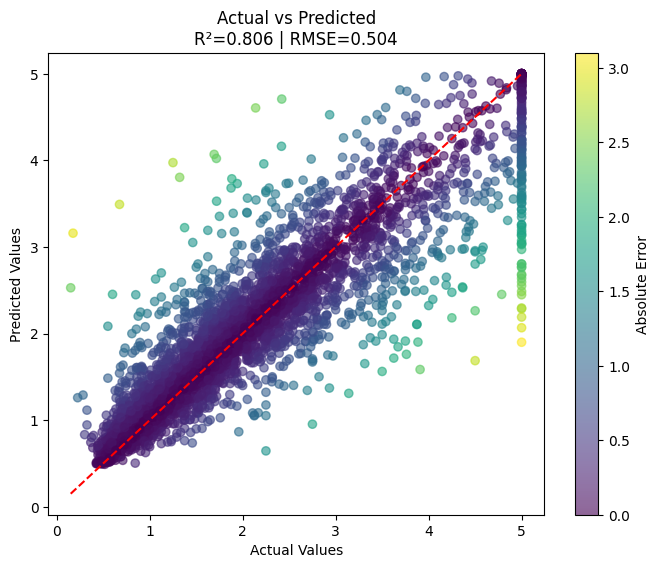

In [40]:
from sklearn.metrics import r2_score, root_mean_squared_error

r2 = r2_score(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    y_test,
    predictions,
    c=comparison_df["Absolute_Error"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(scatter, label="Absolute Error")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title(
    f"Actual vs Predicted\nR²={r2:.3f} | RMSE={rmse:.3f}"
)

plt.show()